In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
import torch

from bibola.spatial_autocorrelation import distance_matrix, similarity_matrix, LIBSA
from bibola.knn import inter_batch_graph, intra_batch_graph
from bibola.utils import extract_flattened_triangle

from bibola.MLP import MultiBatchesMLP

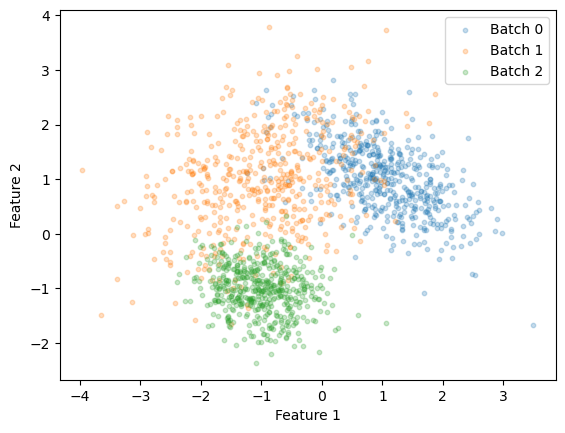

In [15]:
X, batch = make_classification(
    n_samples=1_500, n_features=2, n_classes=3, n_clusters_per_class=1, class_sep=1,
    flip_y=0, n_redundant=0, n_informative=2,
    random_state=1
)
X = torch.tensor(X, dtype=torch.float32)
batch = torch.tensor(batch, dtype=torch.int)


for b in range(batch.max()+1):
    plt.scatter(
        *X[batch==b].T, alpha=.25, s=10,
        label=f"Batch {b}"
    )
    
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

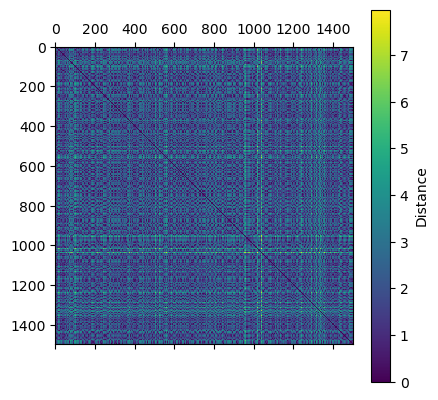

In [16]:
plt.matshow(distance_matrix(X))
plt.colorbar(label="Distance")

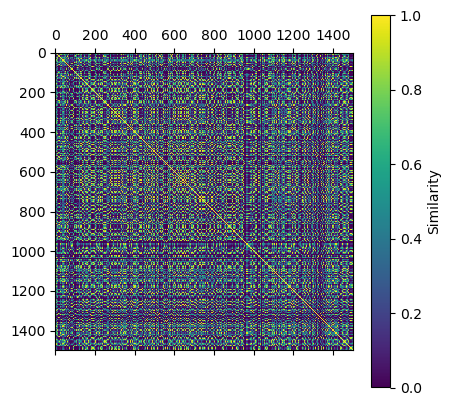

In [17]:
plt.matshow(similarity_matrix(X))
plt.colorbar(label="Similarity")

In [18]:
W = similarity_matrix(X, norm=1)
W.shape

torch.Size([1500, 1500])

In [19]:
# local indicators of batch spatial association (LIBSA)
LIBSA(W, batch) # (n_samples, n_batches) tensor of local indicators of batch spatial association for each sample and batch

tensor([[-4.4366e-02,  5.8821e-01,  3.3847e-01],
        [ 4.7563e-01, -1.2615e-03,  9.4873e-01],
        [ 1.5605e+00,  2.8862e-01,  4.9162e-01],
        ...,
        [ 4.1228e-01,  2.2161e-01,  1.2678e+00],
        [ 9.6966e-02,  7.3505e-01,  2.7056e-01],
        [ 1.6158e-01,  4.1676e-01,  4.6804e-02]])

In [20]:
# positive global autocorrelation due to batch effect
LIBSA(W, batch).mean()

tensor(0.4512)

In [21]:
# null global autocorrelation by permuting the batch labels (no batch effect)
LIBSA(W, batch[torch.randperm(X.size(0))]).mean()

tensor(-7.6680e-05)

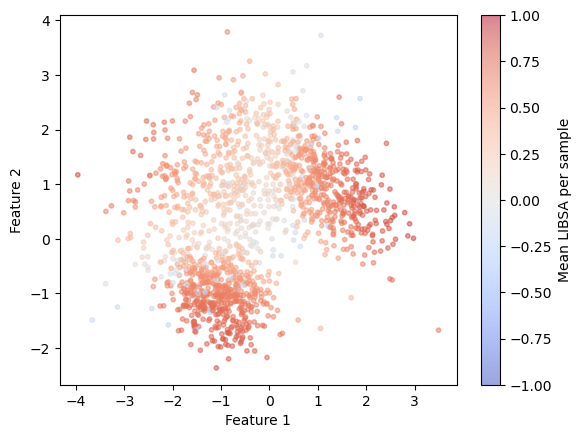

In [22]:
plt.scatter(
    *X.T, alpha=.5, s=10,
    c=LIBSA(W, batch, norm=1).mean(dim=1).numpy(),
    vmin=-1, vmax=1, cmap="coolwarm"
)
plt.colorbar(label="Mean LIBSA per sample")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [23]:
# inter-batch adjacency matrix of the original data
A = inter_batch_graph(X, batch, k=5)
A

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [24]:
# initialize a batch-specific MLP model for batch correction
batch_correction_model = MultiBatchesMLP(
    in_channels=X.size(1),
    hidden_channels=[64,], # single hidden layer with 64 units
    out_channels=2,
    n_batches=batch.max().item() + 1,
    dropout=0.1,
)
batch_correction_model.train() # set the model to training mode

MultiBatchesMLP(
  (mlps): ModuleList(
    (0-2): 3 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=2, out_features=64, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=64, out_features=2, bias=True)
      )
    )
  )
)

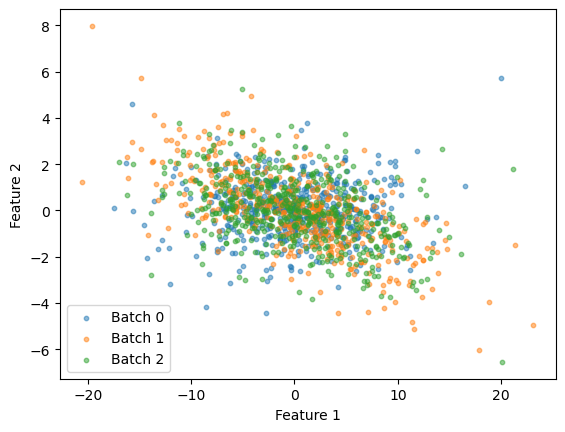

In [26]:
# initial guess for the model parameters
X_transformed = batch_correction_model(X, batch)

for b in range(batch.max()+1):
    plt.scatter(
        *X_transformed[batch==b].detach().T, alpha=.5, s=10,
        label=f"Batch {b}"
    )
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

Epoch 0, Loss: -1.0100786685943604


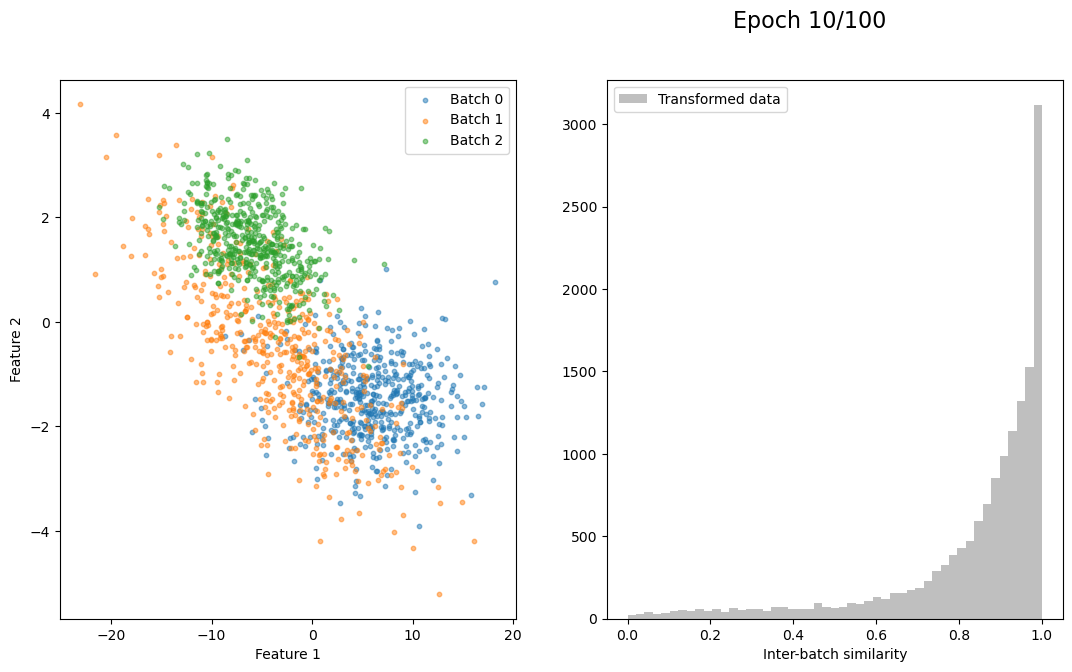

Epoch 0, Loss: -1.0343492031097412


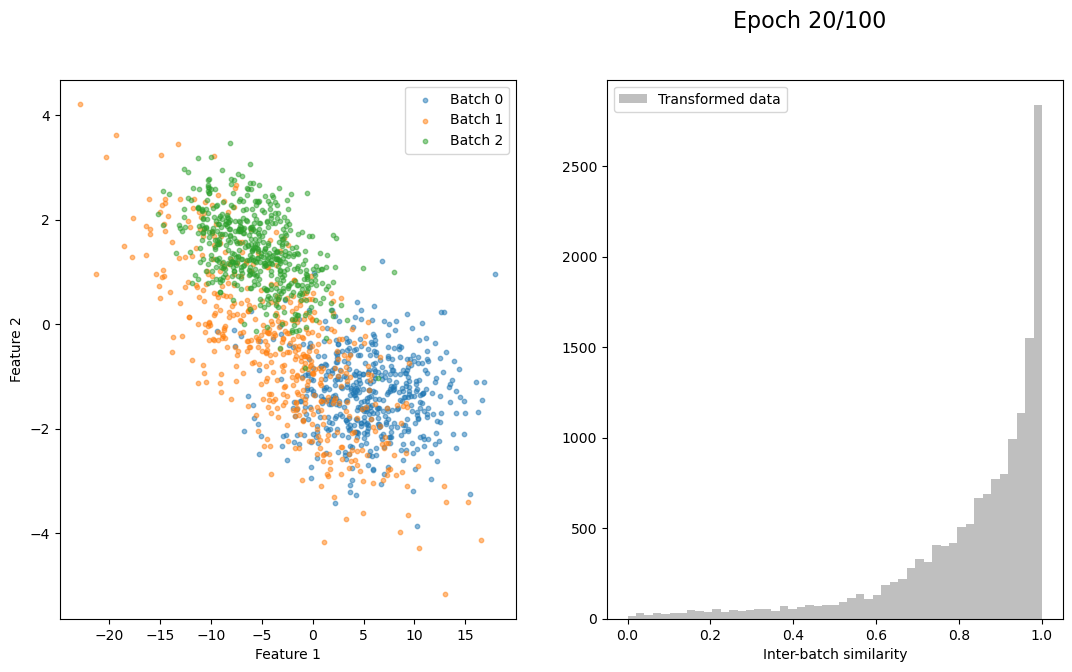

Epoch 0, Loss: -1.0283393859863281


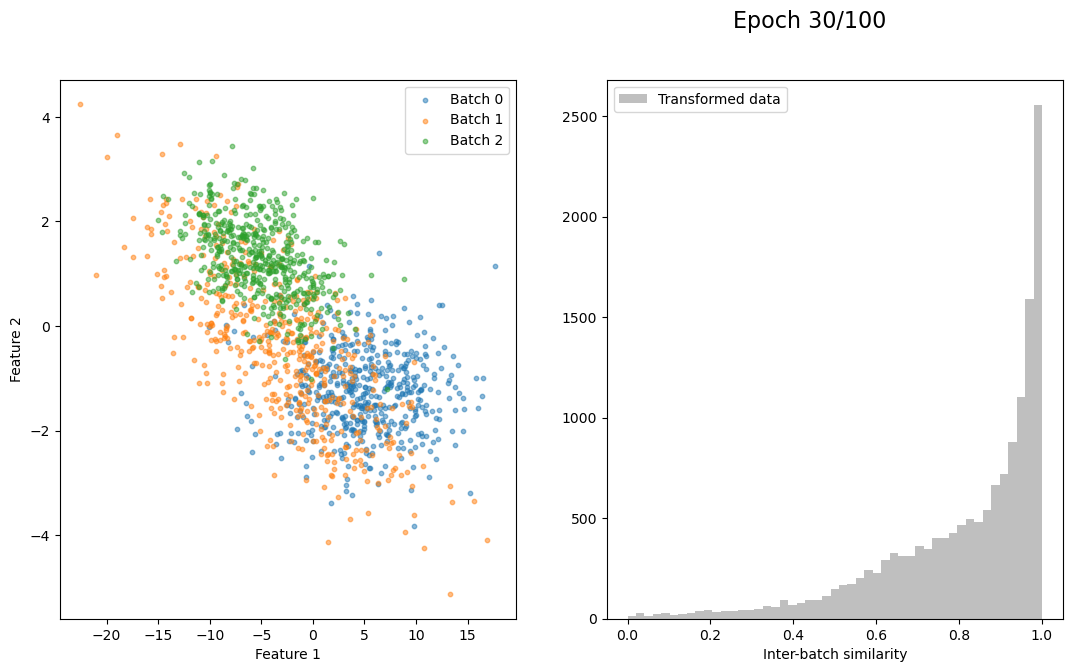

Epoch 0, Loss: -1.0249457359313965


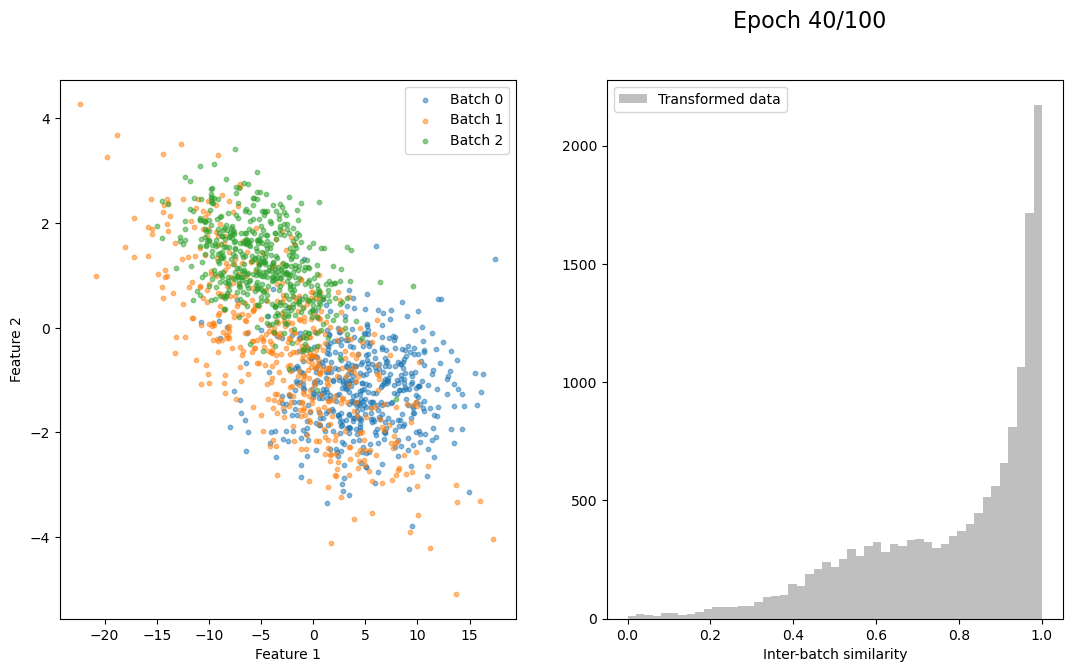

Epoch 0, Loss: -1.0154435634613037


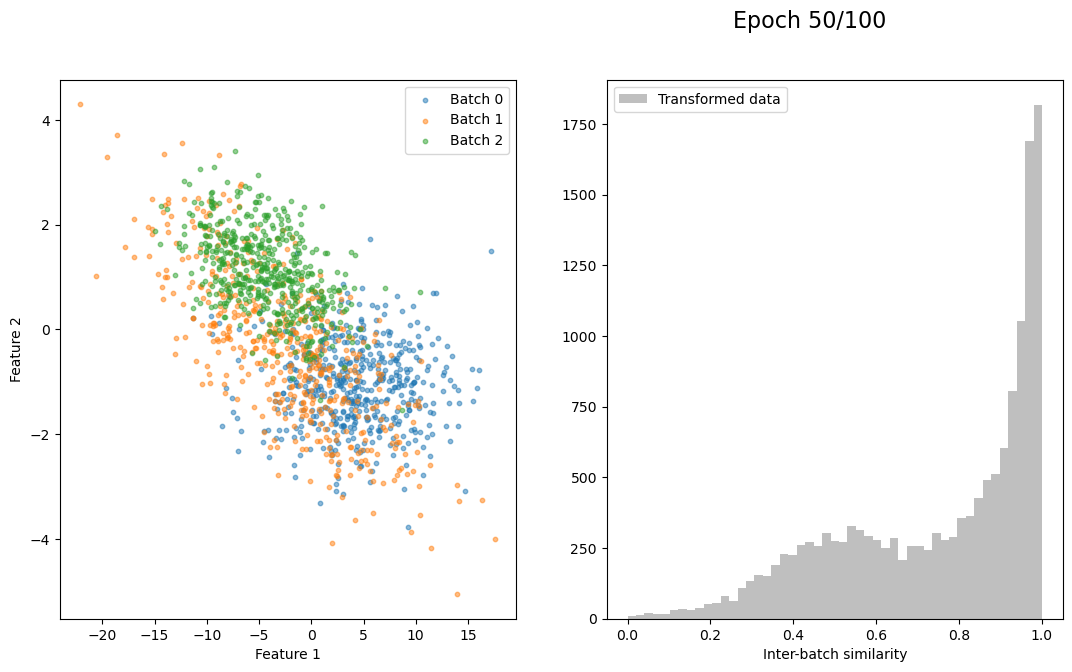

Epoch 0, Loss: -1.0225229263305664


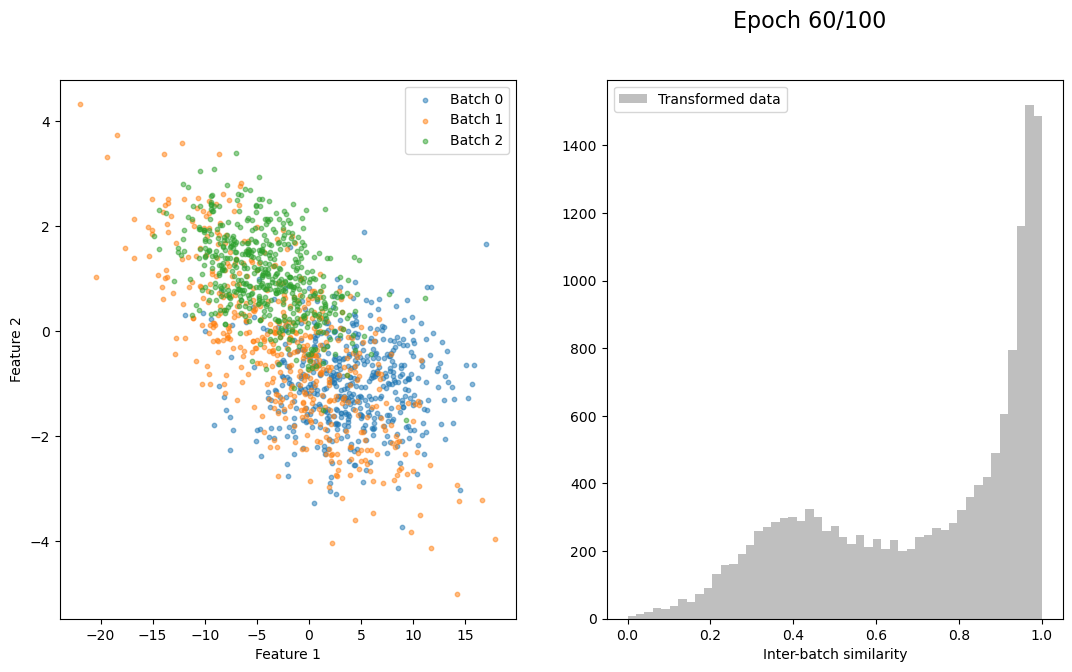

Epoch 0, Loss: -1.0355409383773804


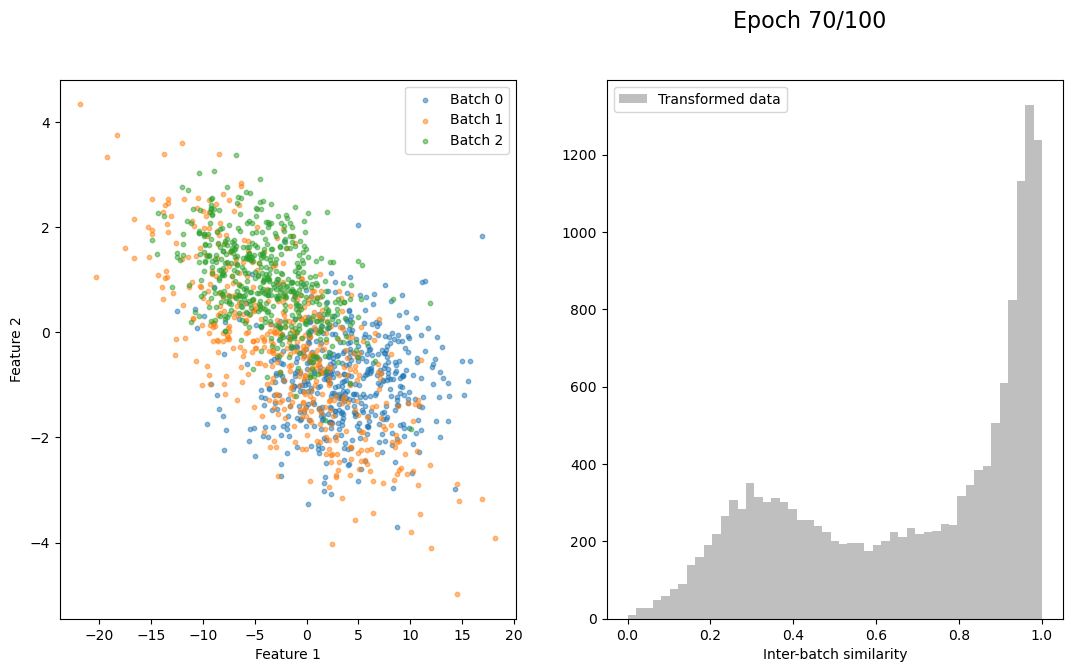

Epoch 0, Loss: -1.042747139930725


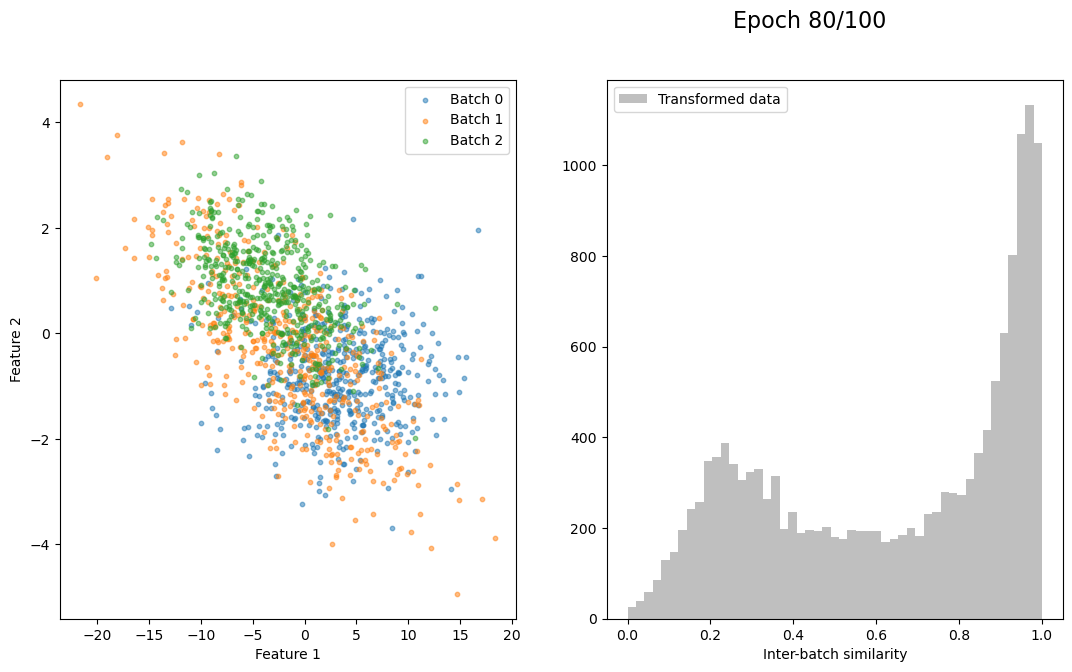

Epoch 0, Loss: -1.0194262266159058


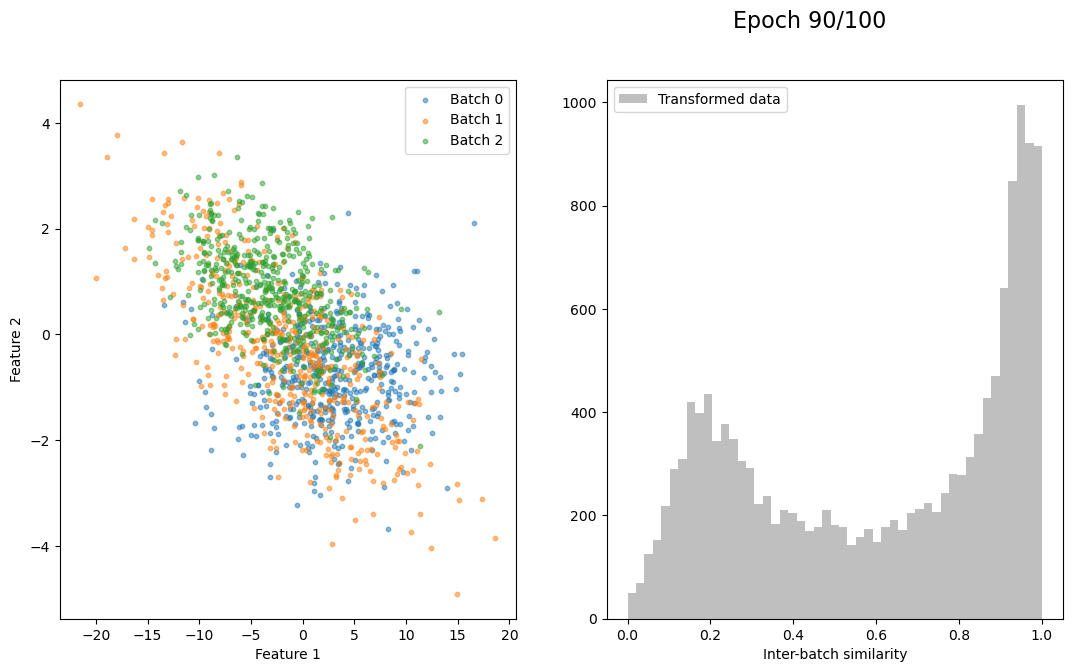

Epoch 0, Loss: -1.032869577407837


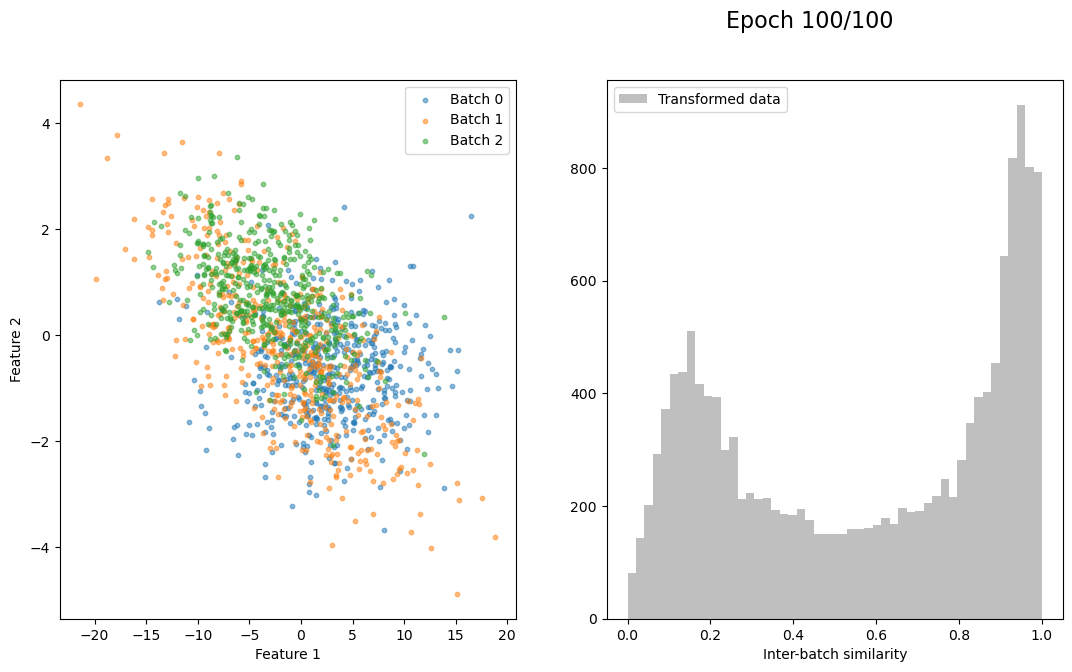

In [27]:
N_EPOCHS = 100

for epoch in range(N_EPOCHS):
    epoch += 1
    if epoch % 10 == 0:
    
        batch_correction_model.train()
        batch_correction_model.fit(X, batch, epochs=1, lr=1e-4, print_every=1, k_inter=5, k_intra=100, norm=2)
        batch_correction_model.eval()
        
        X_transformed = batch_correction_model(X, batch)
        W_transformed = similarity_matrix(X_transformed).detach()
        
        plt.figure(figsize=(20, 7))
        plt.suptitle(f"Epoch {epoch}/{N_EPOCHS}", fontsize=16)
        
        plt.subplot(1, 3, 1)
        for b in range(batch.max()+1):
            plt.scatter(
                *X_transformed[batch==b].detach().T, alpha=.5, s=10,
                label=f"Batch {b}"
            )
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        
        plt.subplot(1, 3, 2)
        # plt.hist(W[A>0], bins=np.linspace(0, 1, 50), alpha=.5, label="Original data")
        plt.hist(W_transformed[A>0], bins=np.linspace(0, 1, 50), alpha=.5, label="Transformed data", color="grey")
        plt.xlabel("Inter-batch similarity")
        plt.legend()
    
        plt.show()

In [28]:
# set the model for inference
batch_correction_model.eval()

MultiBatchesMLP(
  (mlps): ModuleList(
    (0-2): 3 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=2, out_features=64, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=64, out_features=2, bias=True)
      )
    )
  )
)

In [29]:
X_transformed = batch_correction_model(X, batch)
X_transformed

tensor([[  2.3576,  -1.3484],
        [-11.0333,   0.6653],
        [  9.9879,  -1.7578],
        ...,
        [  1.7036,   0.7120],
        [ -0.8413,  -0.9557],
        [ -0.8585,   0.1115]], grad_fn=<ScatterBackward0>)

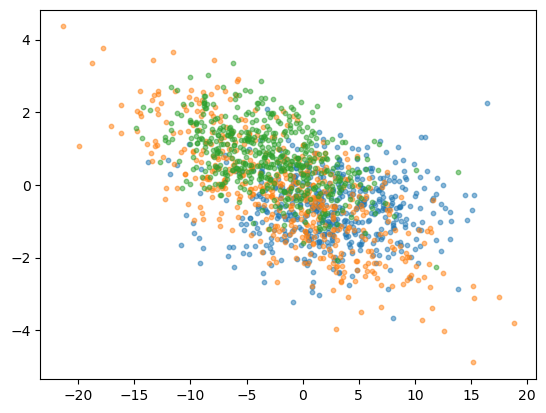

In [30]:
# check the batch effect after the model has been fitted
for b in range(batch.max()+1):
    plt.scatter(
        *X_transformed[batch==b].detach().T, alpha=.5, s=10
    )

In [31]:
# similarity matrix of the transformed data
W_transformed = similarity_matrix(X_transformed).detach()
W_transformed

tensor([[1.0000e+00, 2.2617e-02, 2.9924e-01,  ..., 9.0796e-01, 8.0684e-01,
         7.7278e-01],
        [2.2617e-02, 1.0000e+00, 9.5897e-05,  ..., 3.5008e-02, 1.1072e-01,
         1.1701e-01],
        [2.9924e-01, 9.5897e-05, 1.0000e+00,  ..., 2.1349e-01, 8.7465e-02,
         8.1829e-02],
        ...,
        [9.0796e-01, 3.5008e-02, 2.1349e-01,  ..., 1.0000e+00, 8.2589e-01,
         8.6668e-01],
        [8.0684e-01, 1.1072e-01, 8.7465e-02,  ..., 8.2589e-01, 1.0000e+00,
         9.7674e-01],
        [7.7278e-01, 1.1701e-01, 8.1829e-02,  ..., 8.6668e-01, 9.7674e-01,
         1.0000e+00]])

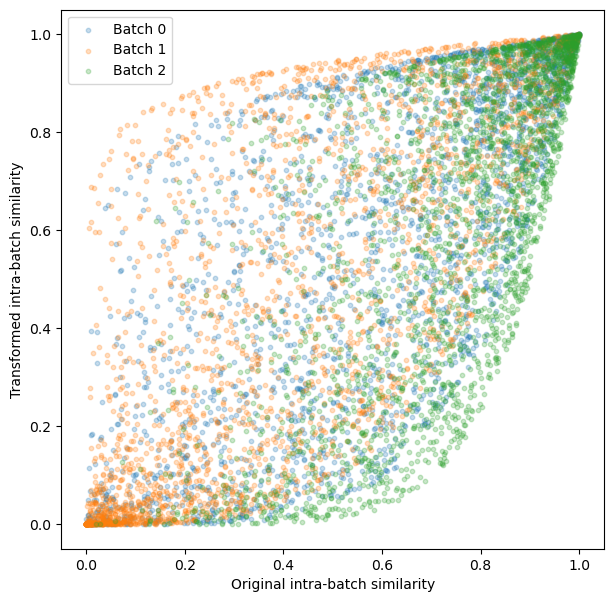

In [32]:
plt.figure(figsize=(7, 7))

for b in range(batch.max()+1):
    plt.scatter(
        extract_flattened_triangle(W[batch==b][:, batch==b])[::50],
        extract_flattened_triangle(W_transformed[batch==b][:, batch==b])[::50],
        alpha=.25, s=10,
        label=f"Batch {b}"
    )
plt.xlabel("Original intra-batch similarity")
plt.ylabel("Transformed intra-batch similarity")
plt.legend()
plt.show()

In [33]:
lisa = LIBSA(W_transformed, batch, norm=1).mean(1)
lisa

tensor([-0.0322,  0.2139,  0.3235,  ..., -0.0232, -0.0245, -0.0291])

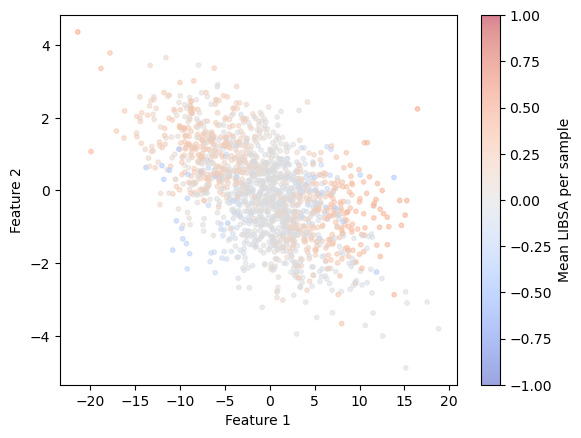

In [34]:
# local indicators of batch spatial association (LIBSA) after batch correction

plt.scatter(
    *X_transformed.detach().T, alpha=.5, s=10,
    c=lisa.detach(), cmap="coolwarm", vmin=-1, vmax=1,
)
plt.colorbar(label="Mean LIBSA per sample")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

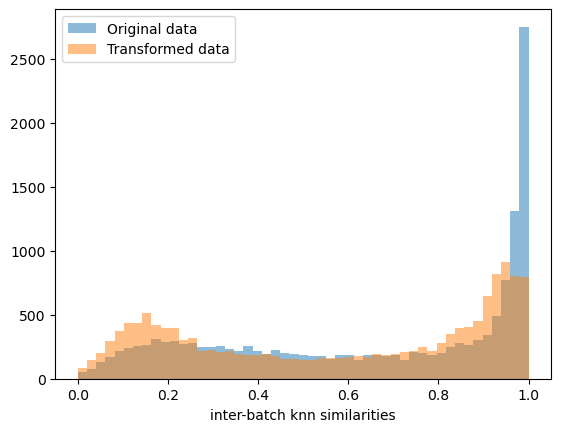

In [36]:
plt.hist(W[A>0], bins=np.linspace(0, 1, 50), alpha=.5, label="Original data")
plt.hist(W_transformed[A>0], bins=np.linspace(0, 1, 50), alpha=.5, label="Transformed data")
plt.xlabel("inter-batch knn similarities")
plt.legend()
plt.show()